# Assignment 1.1 — RGB to HSI Color Model Conversion

## 1. Import Required Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## 2. Load RGB Image

In [4]:
image_path = "../data/input/sample.jpg"

rgb_image = np.array(Image.open(image_path).convert("RGB"))

print("Image shape:", rgb_image.shape)
print("Image data type:", rgb_image.dtype)

Image shape: (480, 640, 3)
Image data type: uint8


## 3. RGB to HSI Conversion

In [5]:
def rgb_to_hsi(rgb_image):
    """Convert an RGB image to HSI."""
    rgb = rgb_image.astype(np.float64)
    if rgb.max() > 1.0:
        rgb = rgb / 255.0

    R = rgb[:, :, 0]
    G = rgb[:, :, 1]
    B = rgb[:, :, 2]

    I = (R + G + B) / 3.0

    rgb_sum = R + G + B
    rgb_min = np.minimum(np.minimum(R, G), B)
    S = np.zeros_like(I)
    nonzero = rgb_sum > 1e-12
    S[nonzero] = 1.0 - (3.0 * rgb_min[nonzero] / rgb_sum[nonzero])

    numerator = 0.5 * ((R - G) + (R - B))
    denominator = np.sqrt((R - G) ** 2 + (R - B) * (G - B))
    H = np.zeros_like(I)
    valid = denominator > 1e-12
    ratio = np.zeros_like(I)
    ratio[valid] = numerator[valid] / denominator[valid]
    ratio = np.clip(ratio, -1.0, 1.0)
    theta = np.degrees(np.arccos(ratio))
    H[valid] = np.where(B[valid] <= G[valid], theta[valid], 360.0 - theta[valid])

    return H, S, I

## 4. Convert RGB Image to HSI

In [6]:
H, S, I = rgb_to_hsi(rgb_image)

print("RGB to HSI conversion completed.")

RGB to HSI conversion completed.


## 5. Display Original RGB Image

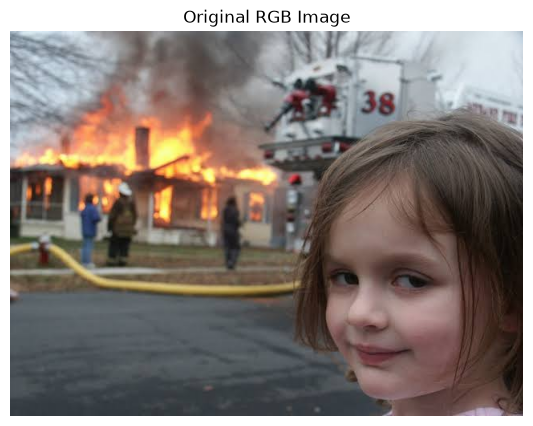

In [7]:
plt.figure(figsize=(7, 5))
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

## 6. Display HSI Components

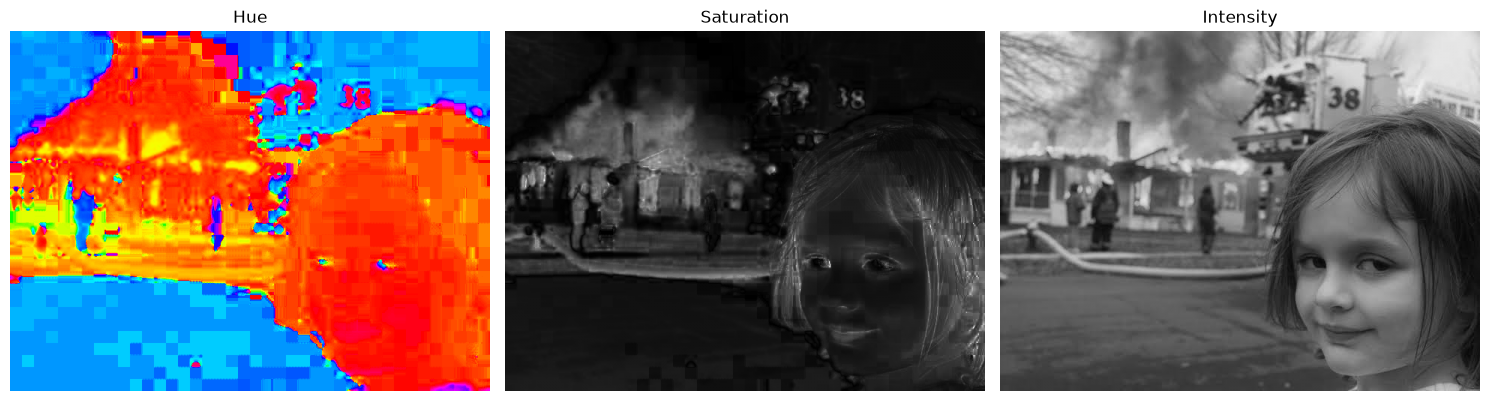

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(H, cmap="hsv", vmin=0, vmax=360)
axes[0].set_title("Hue")
axes[0].axis("off")

axes[1].imshow(S, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Saturation")
axes[1].axis("off")

axes[2].imshow(I, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Intensity")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7. Verify with Basic Color Values

In [9]:
test_pixels = np.array([
    [255, 0, 0],
    [0, 255, 0],
    [0, 0, 255],
    [255, 255, 255],
    [0, 0, 0]
], dtype=np.uint8)

test_image = test_pixels.reshape(5, 1, 3)
H_test, S_test, I_test = rgb_to_hsi(test_image)

colors = ["Red", "Green", "Blue", "White", "Black"]

for i, color in enumerate(colors):
    print(
        f"{color:<6} -> "
        f"H = {H_test[i, 0]:.2f}°, "
        f"S = {S_test[i, 0]:.2f}, "
        f"I = {I_test[i, 0]:.2f}"
    )

Red    -> H = 0.00°, S = 1.00, I = 0.33
Green  -> H = 120.00°, S = 1.00, I = 0.33
Blue   -> H = 240.00°, S = 1.00, I = 0.33
White  -> H = 0.00°, S = 0.00, I = 1.00
Black  -> H = 0.00°, S = 0.00, I = 0.00
